In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [18]:
DATASET_PATH = r"E:\Downloads\Main_2\train_cancer"

IMG_SIZE = 224
BATCH_SIZE = 8   # CPU safe
EPOCHS = 25


In [19]:
print("Dataset Exists:", os.path.exists(DATASET_PATH))
print("Classes Found:", os.listdir(DATASET_PATH))


Dataset Exists: True
Classes Found: ['benign', 'malignant']


In [20]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)


In [21]:
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 216 images belonging to 2 classes.
Found 54 images belonging to 2 classes.


In [22]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


In [23]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_2 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_1               │ (None, 224, 224, 3)       │               7 │ rescaling_2[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_3 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 40)      │           1,080 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 40)      │             160 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 40)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 40)      │             360 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 40)      │             160 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 40)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 40)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 40)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 10)          │             410 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 40)          │             44

 Total params: 11,183,408 (42.66 MB)

 Trainable params: 396,801 (1.51 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3),
    ModelCheckpoint("skin_cancer_model.h5", save_best_only=True)
]


In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4541 - loss: 1.1404

27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 444ms/step - accuracy: 0.4537 - loss: 1.1397 - val_accuracy: 0.6296 - val_loss: 0.6684 - learning_rate: 1.0000e-04
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5864 - loss: 0.8473

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.5875 - loss: 0.8463 - val_accuracy: 0.8333 - val_loss: 0.5401 - learning_rate: 1.0000e-04
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6783 - loss: 0.6488

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.6792 - loss: 0.6478 - val_accuracy: 0.8889 - val_loss: 0.4314 - learning_rate: 1.0000e-04
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7316 - loss: 0.5130

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.7325 - loss: 0.5123 - val_accuracy: 0.9259 - val_loss: 0.3552 - learning_rate: 1.0000e-04
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7959 - loss: 0.5554

...

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.9626 - loss: 0.1521 - val_accuracy: 0.9630 - val_loss: 0.1292 - learning_rate: 1.0000e-04
Epoch 16/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9147 - loss: 0.1561

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.9154 - loss: 0.1554 - val_accuracy: 0.9630 - val_loss: 0.0924 - learning_rate: 1.0000e-04
Epoch 17/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.9254 - loss: 0.1917 - val_accuracy: 0.9630 - val_loss: 0.1194 - learning_rate: 1.0000e-04
Epoch 18/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.9558 - loss: 0.1390 - val_accuracy: 0.9444 - val_loss: 0.1881 - learning_rate: 1.0000e-04
Epoch 19/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8993 - loss: 0.2089

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.8998 - loss: 0.2083 - val_accuracy: 1.0000 - val_loss: 0.0841 - learning_rate: 1.0000e-04
Epoch 20/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 0.9514 - loss: 0.1186 - val_accuracy: 0.9815 - val_loss: 0.0924 - learning_rate: 1.0000e-04
Epoch 21/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.9649 - loss: 0.1100 - val_accuracy: 0.9630 - val_loss: 0.1428 - learning_rate: 1.0000e-04
Epoch 22/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9683 - loss: 0.1145

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.9681 - loss: 0.1150 - val_accuracy: 0.9815 - val_loss: 0.0823 - learning_rate: 1.0000e-04
Epoch 23/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.9599 - loss: 0.1085 - val_accuracy: 0.9444 - val_loss: 0.1037 - learning_rate: 1.0000e-04
Epoch 24/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.9509 - loss: 0.1269 - val_accuracy: 0.9815 - val_loss: 0.1131 - learning_rate: 1.0000e-04
Epoch 25/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9656 - loss: 0.1189

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.9654 - loss: 0.1193 - val_accuracy: 0.9815 - val_loss: 0.0770 - learning_rate: 1.0000e-04


In [26]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.savefig("static/accuracy_graph.png")
plt.close()

In [27]:
model.save("skin_cancer_prediction_model.h5")
print("Model Saved Successfully ✅")


Model Saved Successfully ✅


In [28]:
val_data_eval = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 54 images belonging to 2 classes.


In [29]:
y_pred_probs = model.predict(val_data_eval)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

y_true = val_data_eval.classes


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 596ms/step


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9444444444444444
Precision: 0.9591836734693877
Recall   : 0.9791666666666666
F1 Score : 0.9690721649484536


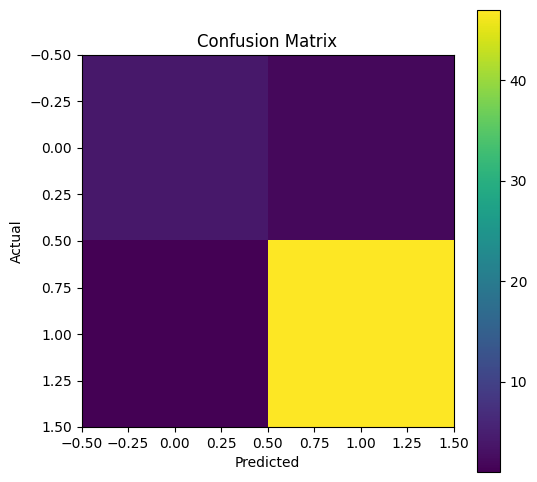

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

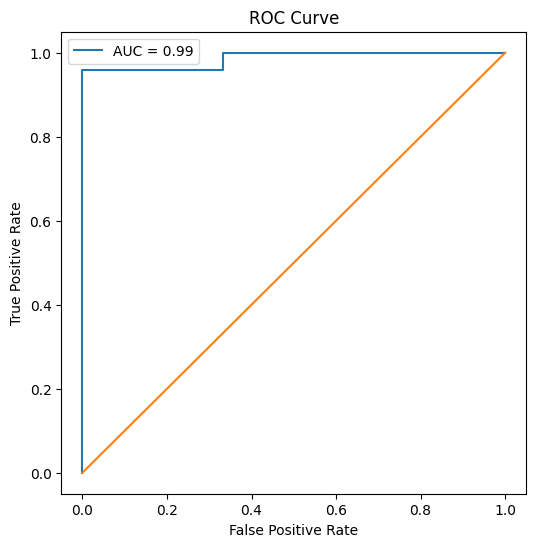

In [32]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("-------- MODEL PERFORMANCE --------")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")


-------- MODEL PERFORMANCE --------
Accuracy  : 94.44%
Precision : 95.92%
Recall    : 97.92%
F1 Score  : 96.91%


In [34]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))



Classification Report:

              precision    recall  f1-score   support

      Benign       0.80      0.67      0.73         6
   Malignant       0.96      0.98      0.97        48

    accuracy                           0.94        54
   macro avg       0.88      0.82      0.85        54
weighted avg       0.94      0.94      0.94        54



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n")
print(cm)


Confusion Matrix:

[[ 4  2]
 [ 1 47]]


In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.savefig("static/confusion_matrix.png")
plt.close()

In [37]:
from tensorflow.keras.preprocessing import image

img_path = r"E:\Downloads\nevus.jpg"   # change this

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: MALIGNANT ")
else:
    print("Prediction: BENIGN ")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: MALIGNANT 
